# Lecture 1 participant notebook: What Should Rotate?

This notebook accompanies Lecture 1. It builds numerical intuition for rotations, invariance, and
equivariance. Run every cell in order. Optional exercises are marked **Try it** and are safe to skip
during the live session.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def random_rotation(rng):
    """Return a random proper 3D rotation using a unit quaternion."""
    q = rng.normal(size=4)
    q /= np.linalg.norm(q)
    w, x, y, z = q
    return np.array([
        [1-2*(y*y+z*z), 2*(x*y-z*w),   2*(x*z+y*w)],
        [2*(x*y+z*w),   1-2*(x*x+z*z), 2*(y*z-x*w)],
        [2*(x*z-y*w),   2*(y*z+x*w),   1-2*(x*x+y*y)],
    ])

## 1. A proper rotation preserves geometry

For a proper rotation, $R^T R=I$ and $\det R=1$. These conditions imply preservation of lengths,
angles, and orientation.

In [2]:
R = random_rotation(rng)
print("max |R.T R - I|:", np.max(np.abs(R.T @ R - np.eye(3))))
print("det(R):", np.linalg.det(R))

u = rng.normal(size=3)
print("length before/after:", np.linalg.norm(u), np.linalg.norm(R @ u))

max |R.T R - I|: 1.1102230246251565e-16
det(R): 0.9999999999999998
length before/after: 2.3491600507712698 2.3491600507712698


## 2. Invariant and equivariant operations

The dot product should remain fixed. The cross product should rotate as a vector.

In [3]:
u, v = rng.normal(size=(2, 3))

dot_before = u @ v
dot_after = (R @ u) @ (R @ v)
cross_route_1 = np.cross(R @ u, R @ v)
cross_route_2 = R @ np.cross(u, v)

print("dot-product invariance error:", abs(dot_after-dot_before))
print("cross-product equivariance error:", np.max(np.abs(cross_route_1-cross_route_2)))

dot-product invariance error: 0.0
cross-product equivariance error: 1.1102230246251565e-16


## 3. A reusable end-to-end test

For a vector-valued function $f(u,v)$, compare $f(Ru,Rv)$ with $Rf(u,v)$.

In [11]:
def equivariance_error(f, U, V, R):
    """Relative maximum error between rotate-then-evaluate and evaluate-then-rotate."""
    lhs = f(U @ R.T, V @ R.T) # rotate the inputs, then evaluate
    rhs = f(U, V) @ R.T       # evaluate, then rotate the output
    return np.max(np.abs(lhs-rhs)) / max(np.max(np.abs(rhs)), 1e-12)

def equivariant_target(U, V):
    return np.sum(U * V, axis=1, keepdims=True) * np.cross(U, V) # row-wise dot product * cross product

def axis_dependent_function(U, V):
    return np.column_stack([U[:, 0], V[:, 1], U[:, 2]]) # not equivariant

U, V = rng.normal(size=(2, 128, 3))
R = random_rotation(rng)
print("equivariant target:", equivariance_error(equivariant_target, U, V, R))
print("axis-dependent function:", equivariance_error(axis_dependent_function, U, V, R))

equivariant target: 1.2048902404382825e-15
axis-dependent function: 1.1809107110173267


## 4. Visualize a rotation

The vectors change coordinates, but their relative angle does not.

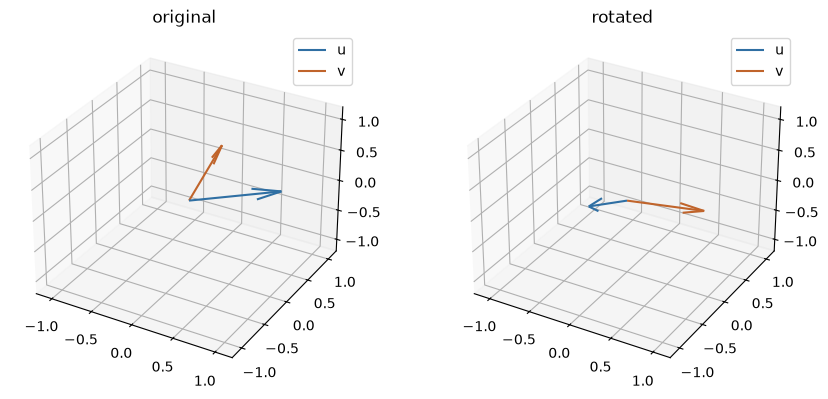

dot products: 0.2 0.1999999999999999


In [12]:
u = np.array([1.0, 0.2, 0.4])
v = np.array([-0.1, 0.9, 0.3])
ur, vr = R @ u, R @ v

fig = plt.figure(figsize=(9, 4))
for k, (a, b, title) in enumerate([(u, v, "original"), (ur, vr, "rotated")], 1):
    ax = fig.add_subplot(1, 2, k, projection="3d")
    ax.quiver(0, 0, 0, *a, color="#2F6FA3", label="u")
    ax.quiver(0, 0, 0, *b, color="#C0642B", label="v")
    ax.set(xlim=(-1.2, 1.2), ylim=(-1.2, 1.2), zlim=(-1.2, 1.2), title=title)
    ax.legend()
plt.tight_layout()
plt.show()
print("dot products:", u @ v, ur @ vr)

## Try it

1. Replace `random_rotation` with a generic random matrix. Which checks fail?
2. Test $f(u,v)=u+v$ and $f(u,v)=(u_x,v_y,u_y)$.
3. Explain why a small prediction error does not automatically imply a small equivariance error.

Use the Lecture 1 solution PDF after discussing your answers.